In [24]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
from matplotlib import pyplot as plt
import time


In [25]:
rootfolder = '.'

Load the image and rescale it in $[0,1]$

In [26]:
img = imread(f'{rootfolder}/data/cameraman.png') / 255
img = img[50:200, 50:200]
imsz = img.shape

# patch size
p = 7

# number of elements in the patch
M = p ** 2

# radius of the search neighborhood
H = 12


Corrupt the image with white gaussian noise

In [27]:
sigma_noise = 20/255
noisy_img = img + np.random.normal(size=imsz)* sigma_noise

Compute the PSNR of the noisy input

In [28]:
psnr_noisy = 10 * np.log10(1/np.mean((img - noisy_img)**2))


Text(0.5, 1.0, 'Noisy image, PSNR = 22.24')

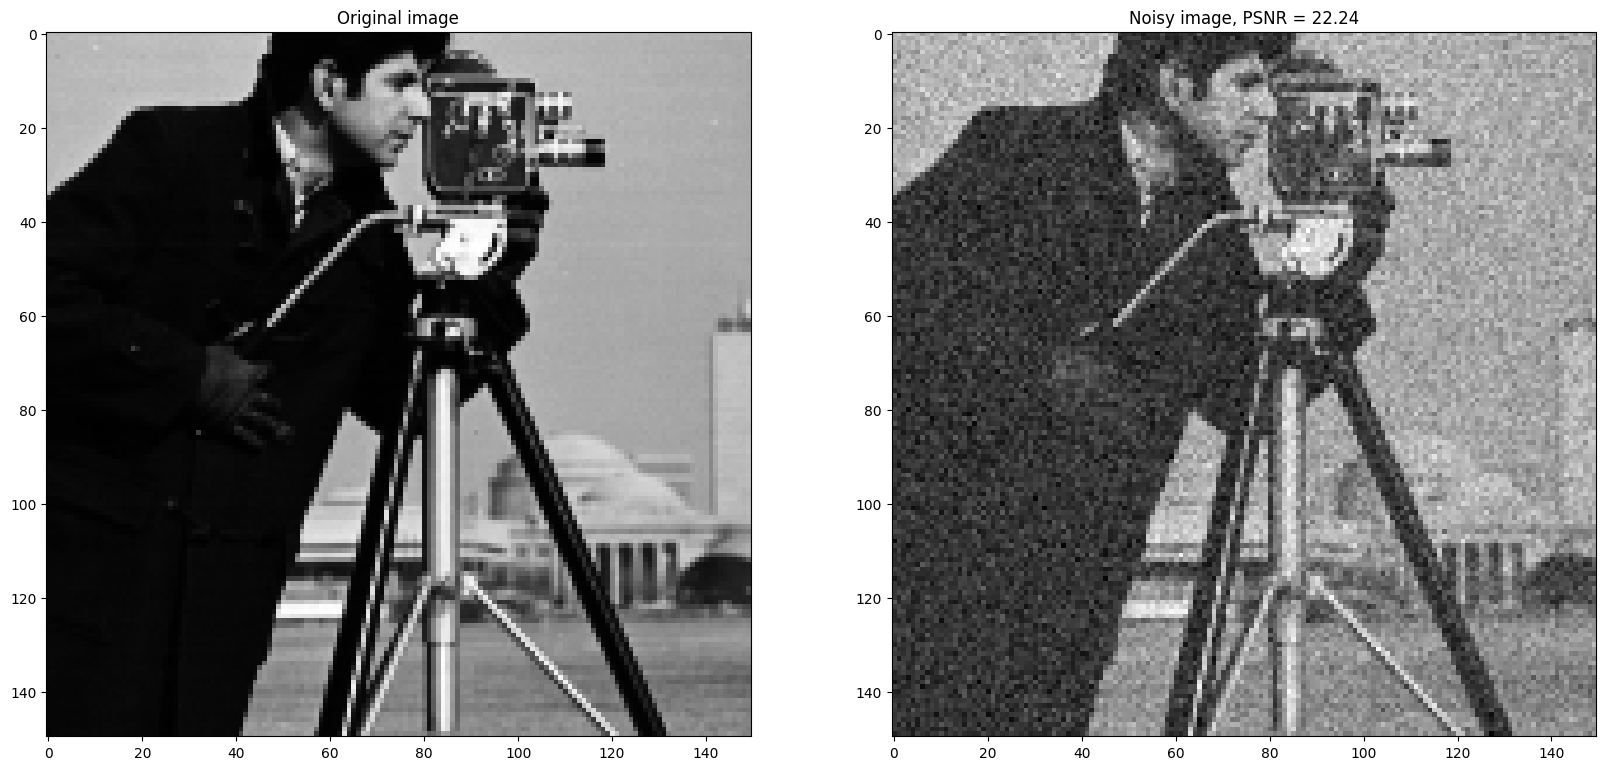

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')


Pixel-based NL-Means
--------------------
Set parameters and initialize the variables

In [30]:
# initialize the estimated image
img_hat = np.zeros_like(img)

# pad the noisy image
img_pad = np.pad(noisy_img, p//2, 'symmetric')


In [31]:
img_pad.shape

(156, 156)

Main loop

In [32]:
for i in range(0, imsz[0]):
    for j in range(0, imsz[1]):
        # extrach the patch from img_pad whose center has the location (i, j) in the noisy image
        s = img_pad[i : i + p, j:j+p]
        print(f"(i,j) --> ({i,j})")
        # initialize the pixel estimate and the total weights
        pixel_hat = 0
        weight = 0

        # extract all the patches in the search neighborhood
        for r in range(-H, H):
            for c in range(-H, H):
                if (i + p //2 + r - p) >= 0 and (j + p //2 + c - p) >= 0 and (i + p //2 + r + p) < imsz[0] and (j + p //2 + c + p) < imsz[1]:
                    # extract the patch
                    z = img_pad[r+i:r+p+i, c+j:c+p+j]

                    # compute the distance with the reference patch
                    d = np.linalg.norm(s-z)**2
                    d = np.exp(-(d/(sigma_noise**2*M))) 

                    #print(f"r + i + p//2 : {r} + {i} + {p//2}  = {r+i+p//2}, z: {z}")
                    # update the weight and the pixel estimate
                    pixel_hat += z[p//2, p//2] *d
                    weight += d

        # estimate the pixel (i, j) as the weighted average of the central pixel of the extracted patches
        img_hat[i, j] = pixel_hat / weight


(i,j) --> ((0, 0))
(i,j) --> ((0, 1))
(i,j) --> ((0, 2))
(i,j) --> ((0, 3))
(i,j) --> ((0, 4))
(i,j) --> ((0, 5))
(i,j) --> ((0, 6))
(i,j) --> ((0, 7))
(i,j) --> ((0, 8))
(i,j) --> ((0, 9))
(i,j) --> ((0, 10))
(i,j) --> ((0, 11))
(i,j) --> ((0, 12))
(i,j) --> ((0, 13))
(i,j) --> ((0, 14))
(i,j) --> ((0, 15))
(i,j) --> ((0, 16))
(i,j) --> ((0, 17))
(i,j) --> ((0, 18))
(i,j) --> ((0, 19))
(i,j) --> ((0, 20))
(i,j) --> ((0, 21))
(i,j) --> ((0, 22))
(i,j) --> ((0, 23))
(i,j) --> ((0, 24))
(i,j) --> ((0, 25))
(i,j) --> ((0, 26))
(i,j) --> ((0, 27))
(i,j) --> ((0, 28))
(i,j) --> ((0, 29))
(i,j) --> ((0, 30))
(i,j) --> ((0, 31))
(i,j) --> ((0, 32))
(i,j) --> ((0, 33))
(i,j) --> ((0, 34))
(i,j) --> ((0, 35))
(i,j) --> ((0, 36))
(i,j) --> ((0, 37))
(i,j) --> ((0, 38))
(i,j) --> ((0, 39))
(i,j) --> ((0, 40))
(i,j) --> ((0, 41))
(i,j) --> ((0, 42))
(i,j) --> ((0, 43))
(i,j) --> ((0, 44))
(i,j) --> ((0, 45))
(i,j) --> ((0, 46))
(i,j) --> ((0, 47))
(i,j) --> ((0, 48))
(i,j) --> ((0, 49))
(i,j) --> 

Compute the PSNR of the estimated image

Text(0.5, 1.0, 'Estimated Image,\nPSNR = 27.01')

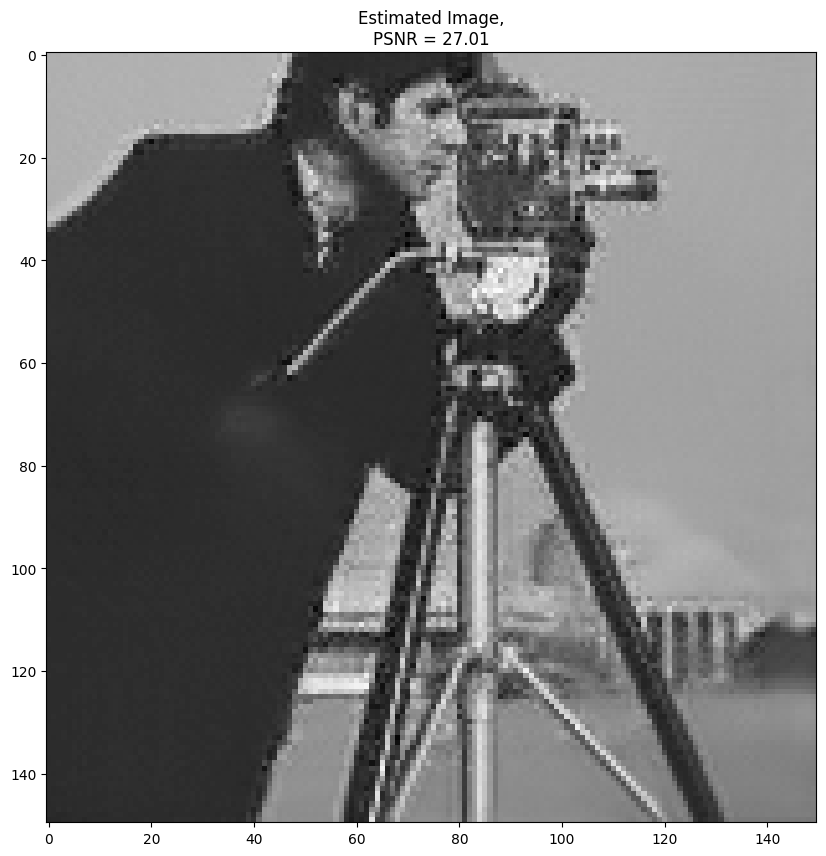

In [34]:
psnr_hat = 10 * np.log10(1/np.mean((img-img_hat)**2))
plt.figure(figsize=(10,10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image,\nPSNR = {psnr_hat:.2f}')
